In [2]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd 

In [3]:
X,y = make_moons(n_samples=300, noise=0.3, random_state=42)

In [4]:
df = pd.DataFrame(X, columns=["Feature 1","Feature 2"])

In [5]:
df["Target"] = y

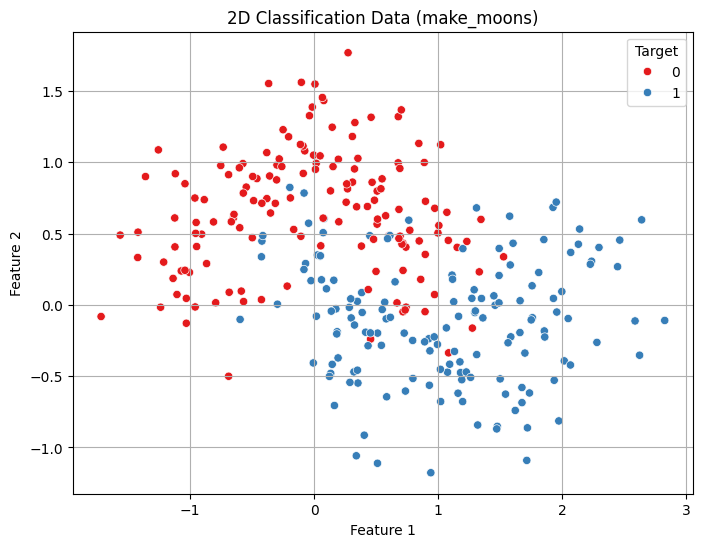

In [9]:
# Visualize the data
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Feature 1", y = "Feature 2", hue = "Target", palette="Set1")
plt.title("2D Classification Data (make_moons)")
plt.grid(True)
plt.show()

In [11]:
# Train - Test Split and Normalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.3)

In [13]:
scaler = StandardScaler()


In [14]:
X_scaled = scaler.fit_transform(X)

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [16]:
model = KNeighborsClassifier(n_neighbors=5)

In [18]:
model.fit(X_train,y_train)

KNeighborsClassifier()

In [20]:
predictions = model.predict(X_test)

In [21]:
print(f"Test accuracy: {accuracy_score(y_test, predictions)} ")

Test accuracy: 0.9222222222222223 


In [22]:
from sklearn.model_selection import cross_val_score
import numpy as np 

In [23]:
k_range = range(1,12)
cv_scores = []

In [24]:
for k in k_range:
    knn=KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

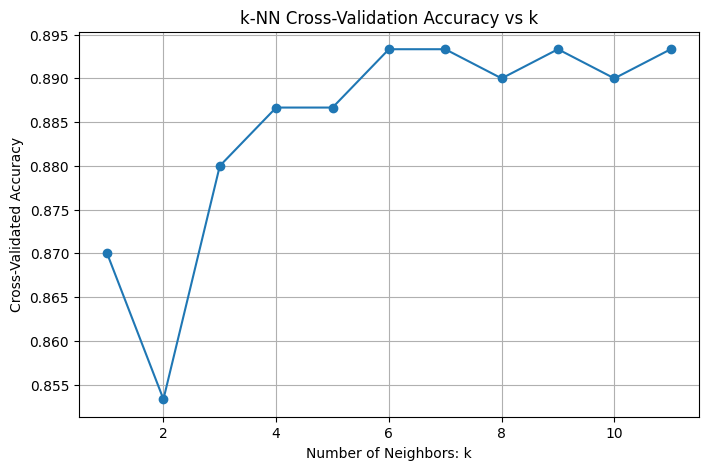

In [25]:
plt.figure(figsize=(8,5))
plt.plot(k_range, cv_scores,marker="o")
plt.title("k-NN Cross-Validation Accuracy vs k")
plt.xlabel("Number of Neighbors: k")
plt.ylabel("Cross-Validated Accuracy")
plt.grid(True)
plt.savefig("figure/k-NN_CV_Accuracy vs K")
plt.show()



In [26]:
best_k = k_range[np.argmax(cv_scores)]
print(f"Best k from cross-validation: {best_k}")

Best k from cross-validation: 6


In [27]:
best_knn = KNeighborsClassifier(n_neighbors=best_k)

In [28]:
best_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=6)

In [29]:
y_pred = best_knn.predict(X_test)

In [30]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [33]:
cm = confusion_matrix(y_test, y_pred)

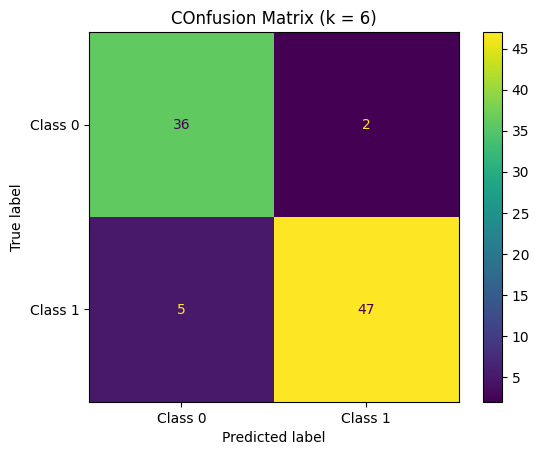

In [34]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot()
plt.title(f"COnfusion Matrix (k = {best_k})")
plt.grid(False)
plt.savefig("figure/confusion_matrix")
plt.show()

In [35]:
print("Classification Report:: ")
print(classification_report(y_test, y_pred))

Classification Report:: 
              precision    recall  f1-score   support

           0       0.88      0.95      0.91        38
           1       0.96      0.90      0.93        52

    accuracy                           0.92        90
   macro avg       0.92      0.93      0.92        90
weighted avg       0.92      0.92      0.92        90



In [36]:
# Visualize the decision boundry

In [37]:
x_min, x_max = X_scaled[:,0].min()-1, X_scaled[:,0].max() + 1
y_min, y_max = X_scaled[:,1].min()-1, X_scaled[:,1].max() + 1

In [38]:
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

In [40]:
Z = best_knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

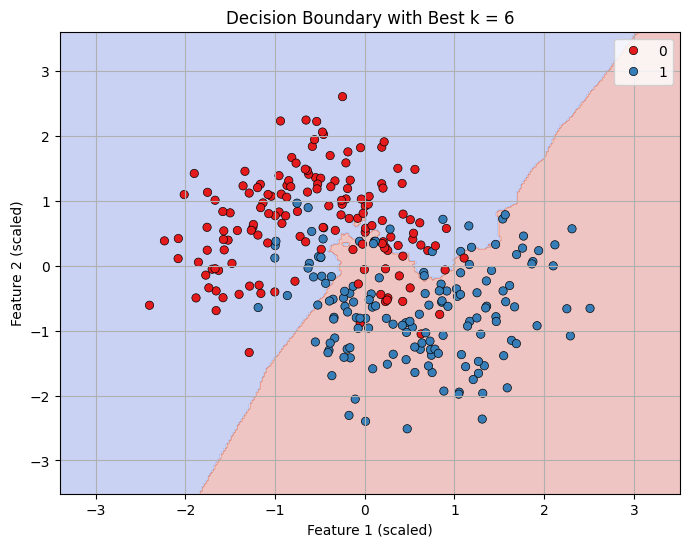

In [44]:
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y, palette="Set1", edgecolor='k')
plt.title(f"Decision Boundary with Best k = {best_k}")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.grid(True)
plt.show()